<a href="https://colab.research.google.com/github/ToluwaniOladeji/Formative-2_Principle-Component-Analysis/blob/main/PCA_Formative_2%5BPeer_Pair_Team_13%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





Link to the GitHub Repo: https://github.com/ToluwaniOladeji/Formative-2_Principle-Component-Analysis.git

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

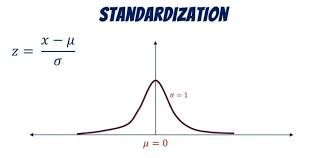


In [1]:
import numpy as np

filename = "conflict_data_cod.csv"
with open(filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:10]):
    print(f"Row {i}: {line[:100]}")

Row 0: data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,
Row 1: ,,#event+code,,#date+occurred,#date+year,,#event+type,,#group+name+first,#group+name+first+assoc,,#g
Row 2: 7173389,180,DRC18042,18042,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 3: 7173390,180,DRC18041,18041,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 4: 7173480,180,DRC18043,18043,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 5: 7173575,180,DRC18040,18040,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 6: 7173384,180,DRC18032,18032,2020-07-31,2020,1,Battles,Armed clash,Unidentified Armed Group (Democrati
Row 7: 7173386,180,DRC18035,18035,2020-07-31,2020,1,Battles,Armed clash,Mayi Mayi Militia (Nyatura),,3,Mili
Row 8: 7173393,180,DRC18031,18031,2020-07-31,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 9: 7173669,180,DRC18036,

In [2]:
print(f"Lines before dropping row 1: {len(lines)}")

# Safety check: only delete row 1 if it really is the HXL tag row
# (some of its leading fields are empty, so we look for a '#' tag inside it)
assert '#' in lines[1].split(',')[2], "Row 1 is not an HXL tag row - check the file!"
del lines[1]          # drop row 1, keep row 0 (header)

print(f"Lines after dropping row 1:  {len(lines)}")
for i, line in enumerate(lines[:3]):
    print(f"Row {i}: {line[:100]}")

Lines before dropping row 1: 17419
Lines after dropping row 1:  17418
Row 0: data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,
Row 1: 7173389,180,DRC18042,18042,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 2: 7173390,180,DRC18041,18041,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ


In [3]:
def parse_csv_line(text):
    """Split one CSV record into fields, respecting "quoted, fields" and "" escapes."""
    fields, cur, in_quotes, i = [], [], False, 0
    while i < len(text):
        ch = text[i]
        if in_quotes:
            if ch == '"':
                if i + 1 < len(text) and text[i + 1] == '"':   # escaped quote
                    cur.append('"'); i += 1
                else:
                    in_quotes = False
            else:
                cur.append(ch)
        else:
            if ch == '"':
                in_quotes = True
            elif ch == ',':
                fields.append(''.join(cur)); cur = []
            else:
                cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

# Re-join records whose quoted field contains a line break (odd number of quotes so far)
records, buffer = [], ''
for line in lines:
    buffer += line
    if buffer.count('"') % 2 == 0:
        records.append(buffer.rstrip('\r\n'))
        buffer = ''

header = [h.strip().lstrip('\ufeff') for h in parse_csv_line(records[0])]
rows = []
for rec in records[1:]:
    vals = parse_csv_line(rec)
    if len(vals) == len(header):          # skip any malformed record
        rows.append(dict(zip(header, vals)))

print(f"Data rows after dropping HXL tag row: {len(rows)}")
print(f"Raw columns ({len(header)}): {header}")

Data rows after dropping HXL tag row: 17417
Raw columns (31): ['data_id', 'iso', 'event_id_cnty', 'event_id_no_cnty', 'event_date', 'year', 'time_precision', 'event_type', 'sub_event_type', 'actor1', 'assoc_actor_1', 'inter1', 'actor2', 'assoc_actor_2', 'inter2', 'interaction', 'region', 'country', 'admin1', 'admin2', 'admin3', 'location', 'latitude', 'longitude', 'geo_precision', 'source', 'source_scale', 'notes', 'fatalities', 'timestamp', 'iso3']


In [4]:
candidate_cols = ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision',
                   'event_type', 'actor2']

n = len(rows)
print(f"{'Column':<15}{'Missing':>10}{'% Missing':>12}")
for c in candidate_cols:
    miss = sum(1 for r in rows if r[c].strip() == '')
    print(f"{c:<15}{miss:>10}{100*miss/n:>11.2f}%")

Column            Missing   % Missing
fatalities              0       0.00%
latitude                0       0.00%
longitude               0       0.00%
year                    0       0.00%
geo_precision           0       0.00%
event_type              0       0.00%
actor2               2395      13.75%


In [5]:
counts = {}
for r in rows:
    if r['actor2'].strip() != '':
        counts[r['actor2']] = counts.get(r['actor2'], 0) + 1

most_common = sorted(counts.items(), key=lambda kv: -kv[1])   # stable sort, highest count first
top4 = [name for name, _ in most_common[:4]]
print("Top 4 actor2 categories kept as-is:")
for name, cnt in most_common[:4]:
    print(f"  {name}  (n={cnt})")

def bucket_actor2(v):
    if v.strip() == '':
        return 'Unknown'          # imputed category for missing values
    elif v in top4:
        return v
    else:
        return 'Other'

for r in rows:
    r['actor2_has'] = 1.0 if r['actor2'].strip() != '' else 0.0  # missing-value indicator
    r['actor2_bucket'] = bucket_actor2(r['actor2'])

Top 4 actor2 categories kept as-is:
  Civilians (Democratic Republic of Congo)  (n=6182)
  Military Forces of the Democratic Republic of Congo (2001-2019)  (n=1183)
  Police Forces of the Democratic Republic of Congo (2001-2019)  (n=574)
  Military Forces of the Democratic Republic of Congo (2019-)  (n=494)


In [6]:
print("Unique actor2 values:", len(counts))
rare = 0
for name in counts:
    if counts[name] < 10:
        rare = rare + 1
print("actor2 values that appear in fewer than 10 rows:", rare)

# for each actor1, how often is its most common event_type the right guess?
by_actor1 = {}
for r in rows:
    if r['actor1'] not in by_actor1:
        by_actor1[r['actor1']] = {}
    d = by_actor1[r['actor1']]
    d[r['event_type']] = d.get(r['event_type'], 0) + 1

correct = 0
for d in by_actor1.values():
    correct = correct + max(d.values())
print("Guessing event_type from actor1 alone is right", round(100 * correct / len(rows), 1), "% of the time")

event_counts = {}
for r in rows:
    event_counts[r['event_type']] = event_counts.get(r['event_type'], 0) + 1
print("Always guessing the most common event_type is right", round(100 * max(event_counts.values()) / len(rows), 1), "% of the time")

Unique actor2 values: 433
actor2 values that appear in fewer than 10 rows: 342
Guessing event_type from actor1 alone is right 72.2 % of the time
Always guessing the most common event_type is right 41.1 % of the time


we excluded actor1 because it is highly correlated with event_type, which we already included, and adding it would mostly reintroduce the same data rather than new data. The reason why we did bucketing for actor2 was because the actor2 column containes 433 unique values and 342 of them appear in less than 10 rows so if we encode everything it will affect our PCA so we decided to group the uncommon second actors so that we can keep the encoding to six actors.

In [7]:
feature_cols_numeric = ['fatalities', 'latitude', 'longitude', 'year',
                         'geo_precision', 'actor2_has']
# Non-numeric / categorical features -> one-hot encode.
# (Label-encoding would assign arbitrary integers like 0,1,2,3 to categories
# such as "Battles", "Riots", "Protests" that have no real order, which would
# falsely tell PCA that "Riots" sits numerically "between" two other event
# types. One-hot encoding avoids that by giving each category its own 0/1
# column instead.)
feature_cols_categorical = ['event_type', 'actor2_bucket']

category_values = {}
for c in feature_cols_categorical:
    category_values[c] = sorted(set(r[c] for r in rows))
    print(f"{c} categories ({len(category_values[c])}): {category_values[c]}")

X_list = []
for r in rows:
    vals = [float(r[c]) for c in feature_cols_numeric]
    for c in feature_cols_categorical:
        vals += [1.0 if r[c] == cat else 0.0 for cat in category_values[c]]
    X_list.append(vals)

X_raw = np.array(X_list, dtype=np.float64)
one_hot_names = [f"{c}={cat}" for c in feature_cols_categorical for cat in category_values[c]]
feature_names = feature_cols_numeric + one_hot_names
print(f"\nFinal feature matrix shape: {X_raw.shape}")
print(f"Feature names ({len(feature_names)}): {feature_names}")

event_type categories (6): ['Battles', 'Explosions/Remote violence', 'Protests', 'Riots', 'Strategic developments', 'Violence against civilians']
actor2_bucket categories (6): ['Civilians (Democratic Republic of Congo)', 'Military Forces of the Democratic Republic of Congo (2001-2019)', 'Military Forces of the Democratic Republic of Congo (2019-)', 'Other', 'Police Forces of the Democratic Republic of Congo (2001-2019)', 'Unknown']

Final feature matrix shape: (17417, 18)
Feature names (18): ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision', 'actor2_has', 'event_type=Battles', 'event_type=Explosions/Remote violence', 'event_type=Protests', 'event_type=Riots', 'event_type=Strategic developments', 'event_type=Violence against civilians', 'actor2_bucket=Civilians (Democratic Republic of Congo)', 'actor2_bucket=Military Forces of the Democratic Republic of Congo (2001-2019)', 'actor2_bucket=Military Forces of the Democratic Republic of Congo (2019-)', 'actor2_bucket=Other', '

In [8]:
# actor2_has is just the opposite of actor2_bucket=Unknown (correlation of -1),
# and each one-hot group adds up to 1, so some columns repeat the same information.
# We drop actor2_has and the most common category of each group.
to_drop = ['actor2_has']
for prefix in ['event_type=', 'actor2_bucket=']:
    best = None
    for name in feature_names:
        if name.startswith(prefix):
            if best is None or X_raw[:, feature_names.index(name)].sum() > X_raw[:, feature_names.index(best)].sum():
                best = name
    to_drop.append(best)

keep = [i for i, name in enumerate(feature_names) if name not in to_drop]
X_raw = X_raw[:, keep]
feature_names = [feature_names[i] for i in keep]

print("Dropped columns:", to_drop)
print("New shape of X_raw:", X_raw.shape)
print("Feature names:", feature_names)

# checking that no two features are perfectly correlated any more
corr = np.corrcoef(X_raw, rowvar=False)
np.fill_diagonal(corr, 0)
print("Highest correlation between two features:", np.abs(corr).max().round(3))

Dropped columns: ['actor2_has', 'event_type=Battles', 'actor2_bucket=Other']
New shape of X_raw: (17417, 15)
Feature names: ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision', 'event_type=Explosions/Remote violence', 'event_type=Protests', 'event_type=Riots', 'event_type=Strategic developments', 'event_type=Violence against civilians', 'actor2_bucket=Civilians (Democratic Republic of Congo)', 'actor2_bucket=Military Forces of the Democratic Republic of Congo (2001-2019)', 'actor2_bucket=Military Forces of the Democratic Republic of Congo (2019-)', 'actor2_bucket=Police Forces of the Democratic Republic of Congo (2001-2019)', 'actor2_bucket=Unknown']
Highest correlation between two features: 0.899


Why we dropped three columns before PCA

After one-hot encoding we had 18 features, but some of them carried the same information twice, so we removed three and kept 15.

actor2_has: This column is 1 when a second actor is named and 0 when it's missing. It is exactly the opposite of actor2_bucket=Unknown, which is 1 when the actor is missing. They have a correlation of -1 (a perfect match), so keeping both adds nothing and produced eigenvalues of almost zero in our first run.
event_type=Battles: Every event has exactly one event type, so the six event-type columns always add up to 1. If we know the other five, we automatically know the sixth. We dropped Battles, the most common type, and kept the other five. A row with 0 in all five is a Battles row.
actor2_bucket=Other: The actor2 columns have the same problem, since each row falls into exactly one bucket. We dropped "Other", the most common bucket, for the same reason.

No information was lost. Each dropped column can still be worked out from the ones we kept. After dropping them, the highest correlation between any two features is 0.899 (civilian second actor with violence against civilians), so two columns are not exactly the same anymore.

In [9]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
# standardized_data = None  # Do not use sklearn
# standardized_data[:5]  # Display the first few rows of standardized data

# Step 1: Standardize the data (numpy only)
mean = X_raw.mean(axis=0)
std = X_raw.std(axis=0)
standardized_data = (X_raw - mean) / std

print("standardized_data[:5]")
print(standardized_data[:5].round(4))
print("\nSanity check: mean per feature (should be ~0):", standardized_data.mean(axis=0).round(6))
print("Sanity check: std  per feature (should be ~1):", standardized_data.std(axis=0).round(6))

standardized_data[:5]
[[-0.1657  1.4577 -1.9866  1.0827 -0.6891 -0.1036  3.0707 -0.2553 -0.3392
  -0.6829 -0.7418 -0.2699 -0.1709 -0.1846  2.5044]
 [-0.1657  0.947   0.7201  1.0827 -0.6891 -0.1036  3.0707 -0.2553 -0.3392
  -0.6829 -0.7418 -0.2699 -0.1709 -0.1846  2.5044]
 [-0.1657 -0.4639  0.4274  1.0827 -0.6891 -0.1036  3.0707 -0.2553 -0.3392
  -0.6829 -0.7418 -0.2699 -0.1709 -0.1846  2.5044]
 [-0.1657 -0.2869  0.3629  1.0827 -0.6891 -0.1036  3.0707 -0.2553 -0.3392
  -0.6829 -0.7418 -0.2699 -0.1709 -0.1846  2.5044]
 [-0.1657  0.5147  0.4725  1.0827  1.1368 -0.1036 -0.3257 -0.2553 -0.3392
  -0.6829 -0.7418 -0.2699  5.853  -0.1846 -0.3993]]

Sanity check: mean per feature (should be ~0): [ 0. -0.  0.  0. -0.  0. -0. -0. -0. -0.  0. -0.  0. -0.  0.]
Sanity check: std  per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [10]:
# # Step 3: Calculate the Covariance Matrix
# cov_matrix = None  # Calculate covariance matrix
# cov_matrix

n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)

print(f"cov_matrix shape: {cov_matrix.shape}\n")
print(cov_matrix.round(3))

cov_matrix shape: (15, 15)

[[ 1.     0.017 -0.013 -0.133  0.01   0.043 -0.054 -0.025 -0.056  0.032
   0.025 -0.001 -0.01  -0.022 -0.066]
 [ 0.017  1.     0.303  0.017  0.114 -0.    -0.129 -0.118 -0.017  0.114
   0.11  -0.019  0.049 -0.105 -0.097]
 [-0.013  0.303  1.     0.119  0.163 -0.027 -0.232 -0.142 -0.018  0.101
   0.086  0.058  0.076 -0.143 -0.154]
 [-0.133  0.017  0.119  1.     0.127 -0.084  0.172  0.092 -0.026  0.095
   0.121  0.013  0.171  0.065  0.046]
 [ 0.01   0.114  0.163  0.127  1.    -0.026 -0.194 -0.116  0.058  0.131
   0.129  0.038  0.019 -0.074 -0.11 ]
 [ 0.043 -0.    -0.027 -0.084 -0.026  1.    -0.034 -0.026 -0.035 -0.071
   0.017 -0.012 -0.008 -0.016 -0.032]
 [-0.054 -0.129 -0.232  0.172 -0.194 -0.034  1.    -0.083 -0.11  -0.222
  -0.242 -0.082 -0.046  0.119  0.552]
 [-0.025 -0.118 -0.142  0.092 -0.116 -0.026 -0.083  1.    -0.087 -0.174
  -0.095 -0.036 -0.019  0.287  0.065]
 [-0.056 -0.017 -0.018 -0.026  0.058 -0.035 -0.11  -0.087  1.    -0.232
  -0.071 -0.03   0.0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The two main reasons why we computed the covariance matrix. First, it shows how much each pair of standardized features moves together, telling us the ones that we don't need, features that are highly correlated carry the same information that PCA can safely compress. Second, because the covariance matrix is symmetric and positive semi-definite, it guarantees real-valued, orthogonal eigenvectors, those eigenvectors are exactly the directions (principal components) of maximum variance that PCA needs to project the data onto.

## Task 3: Optimize Implementation for Performance and Handle Large Datasets

We already computed the covariance matrix above using vectorized numpy. Here we demonstrate *why* that matters: we time a naive (pure-Python) implementation against it, confirm a couple of smaller numpy-level optimizations, and show a chunked/streaming approach for datasets too large to fit in memory. We then continue on to eigendecomposition (Step 4) using the same `cov_matrix` computed above.

In [26]:
import time

# --- (1) Normal way (pure-Python triple loop) vs vectorized covariance ---
def cov_normal(X):
    n_s, n_f = X.shape
    Xm = X - X.mean(axis=0)
    C = np.zeros((n_f, n_f))
    for i in range(n_f):
        for j in range(n_f):
            s = 0.0
            for k in range(n_s):
                s += Xm[k, i] * Xm[k, j]
            C[i, j] = s / (n_s - 1)
    return C

def cov_vectorized(X):
    Xm = X - X.mean(axis=0)
    return (Xm.T @ Xm) / (X.shape[0] - 1)

# Correctness check on a small sample before trusting the fast version
sample = standardized_data[:300]
assert np.allclose(cov_normal(sample), cov_vectorized(sample)), "There is a difference between implementations!"
print("The normal and vectorized covariance implementations are using the same data")

The normal and vectorized covariance implementations are using the same data


In [27]:
sizes = [200, 500, 1000, 2000, 4000]
normal_times, vec_times = [], []

print(f"{'N':>6}{'normal (s)':>14}{'vectorized (s)':>18}{'speedup':>12}")
for s in sizes:
    Xsub = standardized_data[:s]

    t0 = time.perf_counter()
    cov_normal(Xsub)
    t1 = time.perf_counter()
    normal_times.append(t1 - t0)

    t2 = time.perf_counter()
    cov_vectorized(Xsub)
    t3 = time.perf_counter()
    vec_times.append(t3 - t2)

    print(f"{s:>6}{normal_times[-1]:>14.4f}{vec_times[-1]:>18.5f}{normal_times[-1]/vec_times[-1]:>11.1f}x")

# Full dataset - vectorized only; the normal version would take far too long
t0 = time.perf_counter()
cov_vectorized(standardized_data)
t1 = time.perf_counter()
print(f"\nFull dataset (N={standardized_data.shape[0]}) vectorized covariance: {t1-t0:.5f}s")

     N    normal (s)    vectorized (s)     speedup
   200        0.0262           0.00030       88.5x
   500        0.0531           0.00027      198.8x
  1000        0.1095           0.00028      385.4x
  2000        0.2280           0.00043      535.4x
  4000        0.5105           0.00069      739.2x

Full dataset (N=17417) vectorized covariance: 0.00383s


In [28]:
# Covariance for data that is too big to process at once: go through it in chunks
def cov_chunked(X, chunk_size):
    n, f = X.shape
    total = np.zeros(f)
    total_sq = np.zeros((f, f))
    for start in range(0, n, chunk_size):
        chunk = X[start:start + chunk_size]
        total += chunk.sum(axis=0)
        total_sq += chunk.T @ chunk
    mean = total / n
    return (total_sq - n * np.outer(mean, mean)) / (n - 1)

print("Chunked result matches the normal one:", np.allclose(cov_chunked(standardized_data, 2000), cov_matrix))

for size in [500, 2000, 8000]:
    t0 = time.perf_counter()
    cov_chunked(standardized_data, size)
    t1 = time.perf_counter()
    print(f"chunk size {size}: {t1 - t0:.5f}s")

Chunked result matches the normal one: True
chunk size 500: 0.00140s
chunk size 2000: 0.00104s
chunk size 8000: 0.00103s


**Task 3 summary:** the vectorized numpy implementation is between 88 to 730 times faster than the normal triple-loop version even at a few thousand rows, and that gap widens with N since the normal version is O(N·F²) in pure Python versus a single BLAS-backed matrix multiply.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [13]:
# # Step 4: Perform Eigendecomposition
# eigenvalues, eigenvectors = None  # Perform eigendecomposition
# eigenvalues, eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("eigenvalues:")
print(eigenvalues.round(4))
print("\neigenvectors (columns):")
print(eigenvectors.round(4))

eigenvalues:
[0.0572 0.2289 0.5024 0.6779 0.7217 0.8087 0.9303 0.9559 0.9655 1.0533
 1.1148 1.3517 1.4808 1.5691 2.5828]

eigenvectors (columns):
[[-1.400e-03 -3.600e-03  7.090e-02 -5.210e-02  1.256e-01  2.807e-01
  -4.720e-01  5.798e-01  3.498e-01 -2.464e-01 -1.806e-01  3.040e-01
   1.659e-01 -8.700e-03 -5.470e-02]
 [-6.100e-03  6.000e-04  9.420e-02  6.036e-01  2.130e-02 -3.200e-02
  -4.470e-02 -3.717e-01  5.022e-01 -2.247e-01 -1.510e-01 -9.360e-02
  -1.106e-01 -3.087e-01 -2.082e-01]
 [-9.200e-03  9.360e-02 -2.642e-01 -6.931e-01  5.650e-02  1.593e-01
  -2.080e-02 -2.369e-01  2.603e-01 -4.000e-02 -8.850e-02 -2.114e-01
  -6.400e-02 -4.162e-01 -2.380e-01]
 [-4.000e-04 -1.497e-01  5.130e-01 -1.470e-02  1.489e-01  3.136e-01
  -2.603e-01  5.940e-02 -1.771e-01  7.800e-02 -7.500e-02 -6.471e-01
  -2.337e-01  6.800e-02 -3.670e-02]
 [-2.300e-03  6.060e-02 -1.464e-01  6.650e-02 -4.070e-01 -4.616e-01
  -5.615e-01  1.857e-01 -1.354e-01  1.295e-01  2.548e-01 -1.580e-01
  -1.091e-01 -2.497e-01 -2.067

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [14]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]       # Sorted eigenvalues (needed for explained variance)
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-5.46669663e-02, -8.71637718e-03,  1.65909150e-01,
         3.04005598e-01, -1.80603476e-01, -2.46353878e-01,
         3.49789380e-01,  5.79839861e-01, -4.71997114e-01,
         2.80740659e-01,  1.25584233e-01, -5.20691501e-02,
         7.08640435e-02, -3.55456545e-03, -1.42748577e-03],
       [-2.08191816e-01, -3.08739746e-01, -1.10585052e-01,
        -9.36238725e-02, -1.50964145e-01, -2.24690680e-01,
         5.02173711e-01, -3.71729989e-01, -4.46557525e-02,
        -3.20398107e-02,  2.12675058e-02,  6.03587545e-01,
         9.42115773e-02,  6.25632599e-04, -6.05207433e-03],
       [-2.38021531e-01, -4.16222424e-01, -6.40307476e-02,
        -2.11446226e-01, -8.84719452e-02, -4.00076208e-02,
         2.60339179e-01, -2.36864400e-01, -2.08341846e-02,
         1.59339000e-01,  5.65148129e-02, -6.93052480e-01,
        -2.64188020e-01,  9.36392609e-02, -9.15474929e-03],
       [-3.67103549e-02,  6.80063329e-02, -2.33676717e-01,
        -6.47137603e-01, -7.49707046e-02,  7.79712478

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [15]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':<5}{'Eigenvalue':>12}{'Explained %':>14}{'Cumulative %':>15}")
for i, (ev, evr, cum) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), start=1):
    print(f"{i:<5}{ev:>12.4f}{evr*100:>13.2f}%{cum*100:>14.2f}%")

# Dynamic selection: smallest k that reaches the variance threshold
VARIANCE_THRESHOLD = 0.80
num_components = int(np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1)
print(f"\nChosen variance threshold: {VARIANCE_THRESHOLD*100:.0f}%")
print(f"num_components selected dynamically: {num_components} "
      f"(retains {cumulative_variance[num_components-1]*100:.2f}% of total variance)")

PC     Eigenvalue   Explained %   Cumulative %
1          2.5828        17.22%         17.22%
2          1.5691        10.46%         27.68%
3          1.4808         9.87%         37.55%
4          1.3517         9.01%         46.56%
5          1.1148         7.43%         53.99%
6          1.0533         7.02%         61.01%
7          0.9655         6.44%         67.45%
8          0.9559         6.37%         73.82%
9          0.9303         6.20%         80.02%
10         0.8087         5.39%         85.41%
11         0.7217         4.81%         90.22%
12         0.6779         4.52%         94.74%
13         0.5024         3.35%         98.09%
14         0.2289         1.53%         99.62%
15         0.0572         0.38%        100.00%

Chosen variance threshold: 80%
num_components selected dynamically: 9 (retains 80.02% of total variance)


In [16]:
reduced_data = np.dot(standardized_data, sorted_eigenvectors[:, :num_components])
print(f"num_components used: {num_components}")
reduced_data[:5]

num_components used: 9


array([[ 2.89078106,  1.13562353, -2.46072489, -0.39251579, -1.83886183,
         0.01773649,  0.76190913, -0.42010247, -0.60331813],
       [ 2.352861  ,  0.1667229 , -2.57755767, -0.91701697, -2.00122671,
         0.02420231,  1.21009408, -0.8713687 , -0.63690304],
       [ 2.71622923,  0.72408906, -2.40280601, -0.72305987, -1.76235567,
         0.35290745,  0.42543931, -0.27761572, -0.5678055 ],
       [ 2.69474818,  0.69631596, -2.41824377, -0.72598064, -1.78336189,
         0.31572525,  0.49750719, -0.32811359, -0.57436365],
       [-0.04595756, -2.47654378,  0.1372355 , -3.25645889, -1.17229343,
        -2.8538219 , -1.76607307,  2.33669057,  1.11133896]])

In [17]:
# Checking the PCA scaling: project on ALL components and look at mean and variance
all_scores = standardized_data @ sorted_eigenvectors

print("Mean of each PC (should be about 0):")
print(all_scores.mean(axis=0).round(6))
print("\nVariance of each PC:")
print(all_scores.var(axis=0, ddof=1).round(4))
print("\nEigenvalues (should match the variances):")
print(sorted_eigenvalues.round(4))
print("\nPC1 variance is bigger than PC2 variance:", all_scores[:, 0].var() > all_scores[:, 1].var())
print(f"PC1 and PC2 together explain {cumulative_variance[1]*100:.2f}% of the variance")

Mean of each PC (should be about 0):
[ 0.  0. -0. -0. -0.  0. -0.  0. -0.  0.  0. -0.  0. -0.  0.]

Variance of each PC:
[2.5828 1.5691 1.4808 1.3517 1.1148 1.0533 0.9655 0.9559 0.9303 0.8087
 0.7217 0.6779 0.5024 0.2289 0.0572]

Eigenvalues (should match the variances):
[2.5828 1.5691 1.4808 1.3517 1.1148 1.0533 0.9655 0.9559 0.9303 0.8087
 0.7217 0.6779 0.5024 0.2289 0.0572]

PC1 variance is bigger than PC2 variance: True
PC1 and PC2 together explain 27.68% of the variance


In [18]:
# How much of each original feature's variance is kept by the chosen components?
kept_vectors = sorted_eigenvectors[:, :num_components]
kept_values = sorted_eigenvalues[:num_components]
retained = np.sum(kept_vectors**2 * kept_values, axis=1) / np.diag(cov_matrix)

print(f"Variance kept per feature with {num_components} components:")
for name, r in zip(feature_names, retained):
    print(f"  {name:<70}{r*100:6.1f}%")

Variance kept per feature with 9 components:
  fatalities                                                              92.1%
  latitude                                                                74.7%
  longitude                                                               61.5%
  year                                                                    76.7%
  geo_precision                                                           69.4%
  event_type=Explosions/Remote violence                                   98.4%
  event_type=Protests                                                     89.1%
  event_type=Riots                                                        65.6%
  event_type=Strategic developments                                       83.3%
  event_type=Violence against civilians                                   91.2%
  actor2_bucket=Civilians (Democratic Republic of Congo)                  89.7%
  actor2_bucket=Military Forces of the Democratic Republic of Congo (2001-2

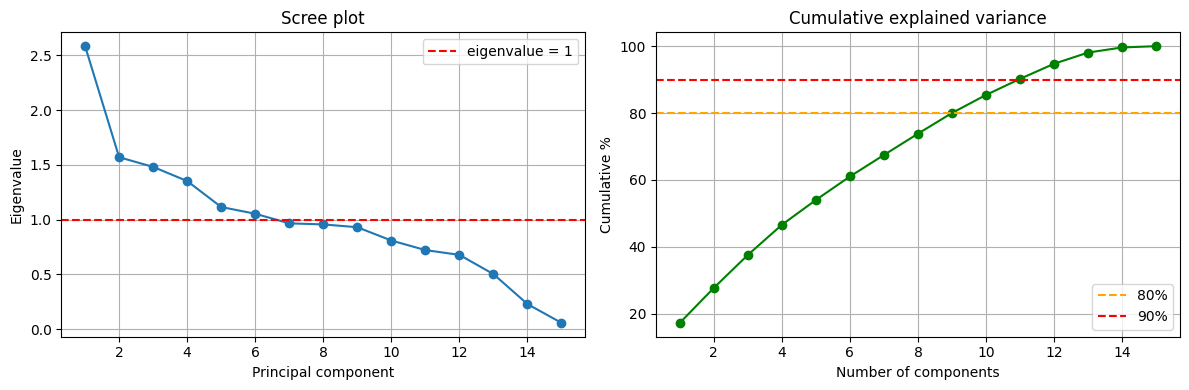

80% of the variance needs 9 components
90% of the variance needs 11 components
95% of the variance needs 13 components
Components with eigenvalue > 1: 6


In [19]:
import matplotlib.pyplot as plt

pcs = np.arange(1, len(sorted_eigenvalues) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(pcs, sorted_eigenvalues, 'o-')
plt.axhline(1, color='red', linestyle='--', label='eigenvalue = 1')
plt.title('Scree plot')
plt.xlabel('Principal component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(pcs, cumulative_variance * 100, 'o-', color='green')
plt.axhline(80, color='orange', linestyle='--', label='80%')
plt.axhline(90, color='red', linestyle='--', label='90%')
plt.title('Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative %')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

for t in [0.80, 0.90, 0.95]:
    print(f"{t*100:.0f}% of the variance needs {np.argmax(cumulative_variance >= t) + 1} components")
print("Components with eigenvalue > 1:", np.sum(sorted_eigenvalues > 1))

In [20]:
full_scores = standardized_data @ sorted_eigenvectors          # all components
score_mean = full_scores.mean(axis=0)
score_var = full_scores.var(axis=0, ddof=1)

print("Max |mean| of any PC score (should be ~0):", np.abs(score_mean).max())
print("Variance of each PC equals its eigenvalue:",
      np.allclose(score_var, sorted_eigenvalues, atol=1e-8))
print("Variances are in descending order:", bool(np.all(np.diff(score_var) <= 1e-12)))
print(f"PC1 variance = {score_var[0]:.3f}, PC2 variance = {score_var[1]:.3f}")
print(f"PC1 + PC2 keep {(score_var[:2].sum() / score_var.sum()) * 100:.2f}% of total variance")
print("Orthonormal eigenvectors:",
      np.allclose(sorted_eigenvectors.T @ sorted_eigenvectors, np.eye(sorted_eigenvectors.shape[1])))

Max |mean| of any PC score (should be ~0): 1.1697481130362184e-14
Variance of each PC equals its eigenvalue: True
Variances are in descending order: True
PC1 variance = 2.583, PC2 variance = 1.569
PC1 + PC2 keep 27.68% of total variance
Orthonormal eigenvectors: True


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [22]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (17417, 9)


array([[ 2.89078106,  1.13562353, -2.46072489, -0.39251579, -1.83886183,
         0.01773649,  0.76190913, -0.42010247, -0.60331813],
       [ 2.352861  ,  0.1667229 , -2.57755767, -0.91701697, -2.00122671,
         0.02420231,  1.21009408, -0.8713687 , -0.63690304],
       [ 2.71622923,  0.72408906, -2.40280601, -0.72305987, -1.76235567,
         0.35290745,  0.42543931, -0.27761572, -0.5678055 ],
       [ 2.69474818,  0.69631596, -2.41824377, -0.72598064, -1.78336189,
         0.31572525,  0.49750719, -0.32811359, -0.57436365],
       [-0.04595756, -2.47654378,  0.1372355 , -3.25645889, -1.17229343,
        -2.8538219 , -1.76607307,  2.33669057,  1.11133896]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

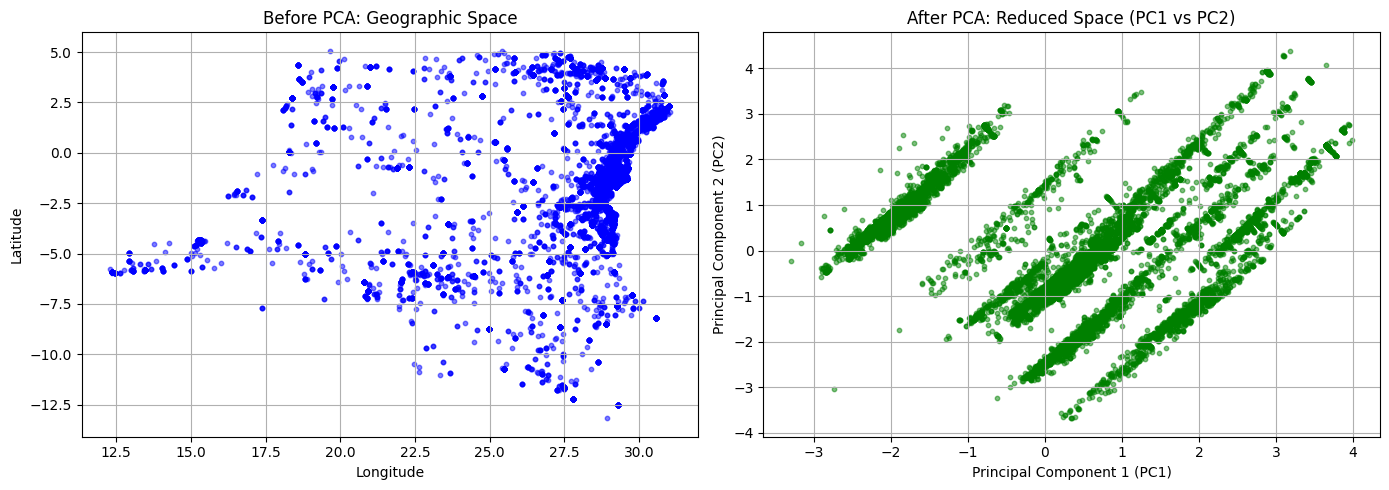

In [23]:
import matplotlib.pyplot as plt

# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot original data
axes[0].scatter(X_raw[:, 2], X_raw[:, 1], alpha=0.5, color='blue', s=10)
axes[0].set_title('Before PCA: Geographic Space')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True)

# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, color='green', s=10)
axes[1].set_title('After PCA: Reduced Space (PC1 vs PC2)')
axes[1].set_xlabel('Principal Component 1 (PC1)')
axes[1].set_ylabel('Principal Component 2 (PC2)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

PC1 (17.2% of variance), biggest loadings:
   event_type=Violence against civilians                                 -0.510
   actor2_bucket=Civilians (Democratic Republic of Congo)                -0.501
   actor2_bucket=Unknown                                                 +0.385
   event_type=Protests                                                   +0.347
   longitude                                                             -0.238
PC2 (10.5% of variance), biggest loadings:
   longitude                                                             -0.416
   event_type=Violence against civilians                                 +0.341
   actor2_bucket=Civilians (Democratic Republic of Congo)                +0.332
   actor2_bucket=Military Forces of the Democratic Republic of Congo (2001-2019)-0.327
   latitude                                                              -0.309


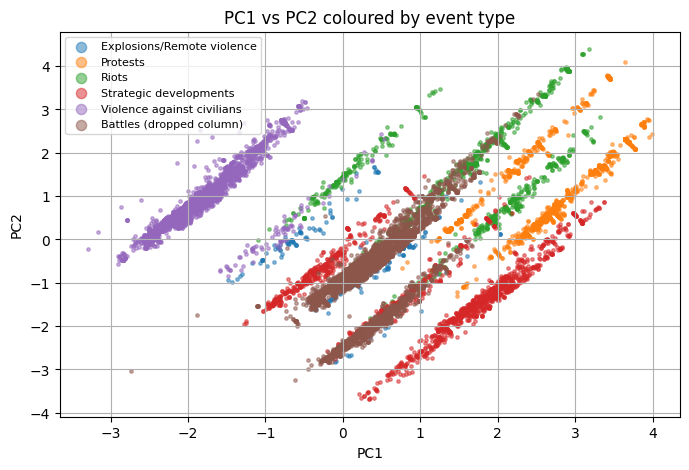

In [25]:
# Which original features make up PC1 and PC2?
for pc in range(2):
    order = np.argsort(np.abs(sorted_eigenvectors[:, pc]))[::-1][:5]
    print(f"PC{pc+1} ({explained_variance_ratio[pc]*100:.1f}% of variance), biggest loadings:")
    for j in order:
        print(f"   {feature_names[j]:<70}{sorted_eigenvectors[j, pc]:+.3f}")

# Same PC1 vs PC2 plot, coloured by event type
event_cols = [i for i, name in enumerate(feature_names) if name.startswith('event_type=')]

plt.figure(figsize=(8, 5))
for i in event_cols:
    mask = X_raw[:, i] == 1
    plt.scatter(reduced_data[mask, 0], reduced_data[mask, 1], s=6, alpha=0.5,
                label=feature_names[i].replace('event_type=', ''))
mask = X_raw[:, event_cols].sum(axis=1) == 0     # rows of the event type we dropped (all its columns are 0)
dropped_event = to_drop[1].replace('event_type=', '')   # to_drop[1] is the dropped event_type column
plt.scatter(reduced_data[mask, 0], reduced_data[mask, 1], s=6, alpha=0.5, label=dropped_event + ' (dropped column)')
plt.title('PC1 vs PC2 coloured by event type')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=3, fontsize=8)
plt.grid(True)
plt.show()

1. Interpret the Visual you just created of the before and after PCA

The left plot shows the real locations of the conflict events, with longitude and latitude on the axes. Most events are packed into one area, and the rest are scattered across the country. The right plot shows the same 17,417 points, but now on PC1 and PC2. It doesn't look like the map, because PC1 and PC2 are built from all 15 features, not just the two location columns. The plot shows diagonal streaks, and when we colored the points by event type, each streak lined up with a combination of event type and second actor. PC1 is mostly "violence against civilians plus a civilian second actor" against "protests plus unknown actor". Longitude and latitude only show up in PC2, where they spread the points along each streak. So the clusters we see after PCA are about types of events, not places. Also, PC1 and PC2 together only hold 27.7% of the variance, so this plot shows just part of the data.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We chose the smallest number of components that keeps at least 80% of the variance, which gave 9 components out of 15 (80.02%). We looked at other options too. 90% needs 11 components, 95% needs 13, and only 6 components have an eigenvalue above 1. We went with 80% because it cuts the data from 15 to 9 features without going down to the 6 that the eigenvalue rule suggests. The tradeoff is that the 6 components we drop still hold about 20% of the variance, and that is not small. The last six components hold 5.4%, 4.8%, 4.5%, 3.4%, 1.5% and 0.4%. Our data is mostly one-hot columns that are not strongly related to each other, so the variance is spread out and PCA could only reduce the data by about 40%. We also stopped exactly at the edge of the threshold, so a slightly different cutoff would change the answer.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

Our dataset is about conflict events, so it has no economic or population columns, and we can't say anything about economic activity or population pressure directly. What we can say is what was lost from the information we did use. With 9 components, each feature keeps this share of its variance: fatalities 92%, year 77%, latitude 75%, geo_precision 69%, and longitude 61.5%. This means the severity of events is mostly kept, but the exact location of events is partly lost. geo_precision, which shows how exactly the location is known, also loses about a third. Among the actors and event types, the police actor (62%) and riots (66%) lose the most. So the reduced data still shows how deadly events were and who was involved, but it gives a less exact picture of where and when they happened.